# Fraud Detection via Graph Features with IEEE-CIS Dataset

Sổ tay này minh họa việc sử dụng cơ sở dữ liệu đồ thị Neo4j và Graph Data Science (GDS) để hỗ trợ quá trình trích xuất đặc trưng cho bài toán phân loại gian lận giao dịch với bộ dữ liệu **IEEE-CIS Fraud Detection dataset**.

In [1]:
import pandas as pd
import getpass
from graphdatascience import GraphDataScience

pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', 500)
pd.set_option('display.max_rows', 50)

### 1. Kết nối tới Neo4j Graph Data Science

Nhập thông tin kết nối Neo4j (URI, Username, Password). Chạy cell này để hiển thị các ô nhập mật khẩu an toàn.

In [2]:
HOST = 'neo4j://localhost'
USERNAME = 'neo4j'
PASSWORD = '12345678' # Thay đổi Password của bạn ở đây
DATABASE = 'dbieee'   # Tên database bạn mới tạo

gds = GraphDataScience(HOST, auth=(USERNAME, PASSWORD), aura_ds=False)

# Trỏ mọi truy vấn tiếp theo vào database mới
gds.set_database(DATABASE)

print(f"Kết nối thành công với Neo4j gds version: {gds.version()} trên db: {DATABASE}")

Kết nối thành công với Neo4j gds version: 2.26.0 trên db: dbieee


### 2. Nạp tập dữ liệu Sample (50k bản ghi)

Chúng ta sẽ đọc 2 bộ dataset sample và nạp vào Neo4j bằng Python.

In [3]:
print("Reading datasets...")
df_trans = pd.read_csv('ieee-fraud-detection/sample_train_transaction.csv')
df_id = pd.read_csv('ieee-fraud-detection/sample_train_identity.csv')

# Merge 2 df
df = df_trans.merge(df_id, how='left', on='TransactionID')
df.fillna('UNKNOWN', inplace=True)
print(f"Total shape: {df.shape}")

Reading datasets...


C:\Users\Tuan\AppData\Local\Temp\ipykernel_2844\3176808890.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'UNKNOWN' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('UNKNOWN', inplace=True)


Total shape: (50000, 434)


### Hướng dẫn Nạp dữ liệu vào Neo4j

Chúng ta sử dụng `UNWIND` theo batches để nạp pandas dataframe vào Neo4j với tốc độ cao. Các nút được thiết lập dựa theo schema:
- `Transaction` nối với `Card`, `Device`, `Email`.

In [4]:
def import_batch_to_neo4j(batch_df):
    query = """
    UNWIND $rows AS row
    
    // Tạo nút Transaction
    MERGE (t:Transaction {id: row.TransactionID})
    SET t.isFraud = toInteger(row.isFraud),
        t.TransactionAmt = toFloat(row.TransactionAmt),
        t.ProductCD = row.ProductCD
    
    // Xử lý nút Card (gộp card1-card6 nếu cần, nhưng đơn giản nhất lấy card1 làm identity tính)
    MERGE (c:Card {id: row.card1})
    MERGE (t)-[:HAS_CARD]->(c)
    
    // Nút Email (P_emaildomain)
    WITH row, t WHERE row.P_emaildomain <> 'UNKNOWN'
    MERGE (e:Email {id: row.P_emaildomain})
    MERGE (t)-[:HAS_P_EMAIL]->(e)
    
    // Nút Device
    WITH row, t WHERE row.DeviceInfo <> 'UNKNOWN'
    MERGE (d:Device {id: row.DeviceInfo})
    MERGE (t)-[:HAS_DEVICE]->(d)
    """
    
    # Convert data into list of dicts for Neo4j
    data = batch_df[['TransactionID', 'isFraud', 'TransactionAmt', 'ProductCD', 
                     'card1', 'P_emaildomain', 'DeviceInfo']].to_dict('records')
    gds.run_cypher(query, params={'rows': data})

# Batch import (chạy ở đoạn này sẽ import thẳng lên neo4j)
batch_size = 5000
import math
total_batches = math.ceil(len(df) / batch_size)

print("Starting import...")
for i in range(total_batches):
    start = i * batch_size
    end = start + batch_size
    batch = df.iloc[start:end]
    import_batch_to_neo4j(batch)
    print(f"Batches done: {i+1} / {total_batches}")
print("Import completed.")

Starting import...
Batches done: 1 / 10
Batches done: 2 / 10
Batches done: 3 / 10
Batches done: 4 / 10
Batches done: 5 / 10
Batches done: 6 / 10
Batches done: 7 / 10
Batches done: 8 / 10
Batches done: 9 / 10
Batches done: 10 / 10
Import completed.


### 3. Trích xuất Đặc trưng Đồ thị (Graph Features) với GDS

Bước đầu tiên, chúng ta dán nhãn `FlaggedTransaction` cho các nút Transaction có dấu hiệu gian lận (`isFraud` = 1).


In [5]:
gds.run_cypher('''
    MATCH(t:Transaction) WHERE t.isFraud = 1 SET t:FlaggedTransaction
    RETURN count(t) AS FlaggedCount
''')


,FlaggedCount
0,1357


#### 3.1. Tính Degree và Flagged Ratio (Tỷ lệ cờ báo)

Đối với mỗi Card, Device, Email, chúng ta sẽ đếm tổng số Giao dịch (Degree) và tổng số Giao dịch Gian lận (Flagged Degree) để tìm ra tỉ lệ rủi ro (`flaggedRatio`).


In [6]:
print("Tính toán các thuộc tính rủi ro cho Card...")
gds.run_cypher('''
    MATCH (c:Card)
    WITH c, 
         COUNT { (c)<-[:HAS_CARD]-(:Transaction) } AS degree, 
         COUNT { (c)<-[:HAS_CARD]-(:FlaggedTransaction) } AS flaggedDegree
    SET c.degree = degree,
        c.flaggedDegree = flaggedDegree,
        c.flaggedRatio = CASE WHEN degree > 0 THEN toFloat(flaggedDegree)/toFloat(degree) ELSE 0.0 END
''')

print("Tính toán cho Device...")
gds.run_cypher('''
    MATCH (d:Device)
    WITH d,
         COUNT { (d)<-[:HAS_DEVICE]-(:Transaction) } AS degree,
         COUNT { (d)<-[:HAS_DEVICE]-(:FlaggedTransaction) } AS flaggedDegree
    SET d.degree = degree, d.flaggedDegree = flaggedDegree,
        d.flaggedRatio = CASE WHEN degree > 0 THEN toFloat(flaggedDegree)/toFloat(degree) ELSE 0.0 END
''')

print("Tính toán cho Email...")
gds.run_cypher('''
    MATCH (e:Email)
    WITH e,
         COUNT { (e)<-[:HAS_P_EMAIL]-(:Transaction) } AS degree,
         COUNT { (e)<-[:HAS_P_EMAIL]-(:FlaggedTransaction) } AS flaggedDegree
    SET e.degree = degree, e.flaggedDegree = flaggedDegree,
        e.flaggedRatio = CASE WHEN degree > 0 THEN toFloat(flaggedDegree)/toFloat(degree) ELSE 0.0 END
''')
print("Hoàn tất tính Degree Centralities.")


Tính toán các thuộc tính rủi ro cho Card...
Tính toán cho Device...
Tính toán cho Email...
Hoàn tất tính Degree Centralities.


Kế tiếp, chúng ta đẩy ngược các chỉ số rủi ro của môi trường (Card, Device, Email) về lại Node Transaction ban đầu. Điều này đại diện cho kiến thức: *"Giao dịch này đang sử dụng thiết bị có lịch sử gian lận cao hay thấp?"*


In [7]:
gds.run_cypher('''
    MATCH (t:Transaction)-[:HAS_CARD]->(c:Card)
    SET t.card_degree = c.degree, t.card_flaggedRatio = c.flaggedRatio
''')
gds.run_cypher('''
    MATCH (t:Transaction)-[:HAS_DEVICE]->(d:Device)
    SET t.device_degree = d.degree, t.device_flaggedRatio = d.flaggedRatio
''')
gds.run_cypher('''
    MATCH (t:Transaction)-[:HAS_P_EMAIL]->(e:Email)
    SET t.email_degree = e.degree, t.email_flaggedRatio = e.flaggedRatio
''')


""


#### 3.2. Thuật toán Community Detection (Louvain)

Thuật toán Louvain sẽ nhóm các giao dịch, thẻ, thiết bị lại thành các cụm (communities) dựa trên sự liên kết chằng chịt của chúng. Một ID cộng đồng (`louvainCommunityId`) sẽ được gán cho mỗi Node.


In [8]:
def clear_graph_by_name(g_name):
    if gds.graph.exists(g_name).exists:
        g = gds.graph.get(g_name)
        gds.graph.drop(g)

clear_graph_by_name('ieee-comm-projection')

print("Projecting graph into memory...")
g, _ = gds.graph.project('ieee-comm-projection', 
    ['Transaction', 'Card', 'Device', 'Email'], 
    {
        'HAS_CARD': {'orientation': 'UNDIRECTED'},
        'HAS_DEVICE': {'orientation': 'UNDIRECTED'},
        'HAS_P_EMAIL': {'orientation': 'UNDIRECTED'}
    }
)

print("Running Louvain Community Detection...")
res = gds.louvain.write(g, writeProperty='louvainCommunityId')
print(f"Tìm thấy {res['communityCount']} cụm cộng đồng.")
g.drop()


Projecting graph into memory...
Running Louvain Community Detection...


 Louvain:   7%|6         | 6.93/100 [00:00<?, ?%/s]

Tìm thấy 558 cụm cộng đồng.


graphName                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               ieee-comm-projection
database                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

#### 3.3 Đưa các tính năng về Pandas DataFrame
Viết truy vấn kéo toàn bộ Graph Features (bao gồm degree, ratios, và communityId) vừa tính về DataFrame Python để chuẩn bị merge.


In [9]:
print("Đang lấy Graph Features từ Neo4j...")
df_graph_features = gds.run_cypher('''
    MATCH (t:Transaction)
    RETURN t.id AS TransactionID,
           t.card_degree AS card_degree,
           t.card_flaggedRatio AS card_flaggedRatio,
           t.device_degree AS device_degree,
           t.device_flaggedRatio AS device_flaggedRatio,
           t.email_degree AS email_degree,
           t.email_flaggedRatio AS email_flaggedRatio,
           t.louvainCommunityId AS louvainCommunityId
''')
df_graph_features['TransactionID'] = df_graph_features['TransactionID'].astype('int64')
print(f"Lấy thành công {len(df_graph_features)} dòng Graph Features!")
df_graph_features.head()


Đang lấy Graph Features từ Neo4j...
Lấy thành công 50000 dòng Graph Features!


,TransactionID,card_degree,card_flaggedRatio,device_degree,device_flaggedRatio,email_degree,email_flaggedRatio,louvainCommunityId
0,2987000,4,0.000000,NaN,NaN,NaN,NaN,8848
1,2987001,75,0.066667,NaN,NaN,17909.0,0.035625,188
2,2987002,69,0.014493,NaN,NaN,360.0,0.080556,231
3,2987003,363,0.019284,NaN,NaN,8360.0,0.014474,1399
4,2987004,1,0.000000,2.0,0.0,17909.0,0.035625,612


## 4. Chuẩn bị Dữ liệu (Data Preprocessing) & Hợp nhất Đặc trưng
Trong phần này chúng ta sẽ Gộp (Merge) `Graph Features` từ Neo4j vào lại dữ liệu Tabular gốc. Sau đó xử lý các cột (Fill NA, Label Encoding).


In [10]:
print("Hợp nhất dữ liệu...")
final_df = df.merge(df_graph_features, on='TransactionID', how='left')

# Fill NA cho các Graph Features (Ví dụ giao dịch không có Card/Device/Email sẽ bị null)
graph_cols = ['card_degree', 'card_flaggedRatio',
              'device_degree', 'device_flaggedRatio',
              'email_degree', 'email_flaggedRatio']

for col in graph_cols:
    final_df[col] = final_df[col].fillna(0)

final_df['louvainCommunityId'] = final_df['louvainCommunityId'].fillna(-1)
print(f"Kích thước sau khi Merge: {final_df.shape}")


Hợp nhất dữ liệu...
Kích thước sau khi Merge: (50000, 441)


### 4.1. Label Encoding cho phân loại Model
Các mô hình cây quyết định (XGBoost/LightGBM) ưu tiên Label Encoding cho các tính năng phân loại (Categories).


In [11]:
from sklearn.preprocessing import LabelEncoder

# Liệt kê các categorical columns cơ bản của IEEE dataset
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 
            'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
            'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 
            'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 
            'DeviceType', 'DeviceInfo']

# Mở rộng những cột có kiểu Object string 
for col in final_df.columns:
    if final_df[col].dtype == 'object':
        if col not in cat_cols:
            cat_cols.append(col)
        # Ép về chuỗi chuẩn để không bị lỗi LabelEncoder
        final_df[col] = final_df[col].astype(str)

print("Encoding Categorical Features...")
for col in cat_cols:
    if col in final_df.columns:
        le = LabelEncoder()
        # Encode và đổi null/UNKWNON thành số luôn
        final_df[col] = le.fit_transform(final_df[col].astype(str))
print("Hoàn tất Encode!")


Encoding Categorical Features...
Hoàn tất Encode!


## 5. Machine Learning Modeling (Baseline vs Graph)
Mình tiến hành chia Features: `X_baseline` gồm ròng dữ liệu cũ và `X_graph` bao bọc thêm Features đồ thị.


In [12]:
from sklearn.model_selection import train_test_split

# Loại bỏ TransactionID và nắp biến isFraud 
features_to_drop = ['TransactionID', 'TransactionDT', 'isFraud']

X = final_df.drop(columns=features_to_drop)
y = final_df['isFraud']

# Định nghĩa danh sách các features đồ thị
graph_features = graph_cols + ['louvainCommunityId']

X_baseline = X.drop(columns=graph_features)
X_graph = X.copy() # Chứa đầy đủ cả hai

# Chia tập test/train (Sử dụng tỷ lệ 80-20)
X_base_train, X_base_test, y_train, y_test = train_test_split(X_baseline, y, test_size=0.2, random_state=42, stratify=y)
X_graph_train, X_graph_test, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tập Train: {X_base_train.shape[0]} dòng, Tập Test: {X_base_test.shape[0]} dòng.")


Tập Train: 40000 dòng, Tập Test: 10000 dòng.


#### Training & Đánh giá Model
Mình sẽ sử dụng thư viện `LightGBM` (rất nhẹ, chạy cực nhanh) để tạo hai Models riêng biệt.


In [13]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, f1_score

params = {
    'objective': 'binary', 
    'n_estimators': 200,
    'learning_rate': 0.1,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

print("--- Đang huấn luyện Mô Hình Baseline ---")
clf_base = lgb.LGBMClassifier(**params)
clf_base.fit(X_base_train, y_train)
base_preds = clf_base.predict(X_base_test)
base_probs = clf_base.predict_proba(X_base_test)[:, 1]
base_auc = roc_auc_score(y_test, base_probs)

print("\n--- Đang huấn luyện Mô Hình Graph ---")
clf_graph = lgb.LGBMClassifier(**params)
clf_graph.fit(X_graph_train, y_train)
graph_preds = clf_graph.predict(X_graph_test)
graph_probs = clf_graph.predict_proba(X_graph_test)[:, 1]
graph_auc = roc_auc_score(y_test, graph_probs)

print("\n=================== KẾT QUẢ ĐÁNH GIÁ ===================")
print(f"[BASELINE] AUC ROC = {base_auc:.4f} | F1-Score = {f1_score(y_test, base_preds):.4f}")
print(f"[ GRAPH  ] AUC ROC = {graph_auc:.4f} | F1-Score = {f1_score(y_test, graph_preds):.4f}")
print("\n*** Báo cáo phân loại cho Graph Model ***")
print(classification_report(y_test, graph_preds))


--- Đang huấn luyện Mô Hình Baseline ---

--- Đang huấn luyện Mô Hình Graph ---

=================== KẾT QUẢ ĐÁNH GIÁ ===================
[BASELINE] AUC ROC = 0.9423 | F1-Score = 0.6979
[ GRAPH  ] AUC ROC = 0.9720 | F1-Score = 0.7592

*** Báo cáo phân loại cho Graph Model ***
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9729
           1       0.92      0.65      0.76       271

    accuracy                           0.99     10000
   macro avg       0.96      0.82      0.88     10000
weighted avg       0.99      0.99      0.99     10000



#### Mức độ quan trọng (Feature Importances) của Graph Features


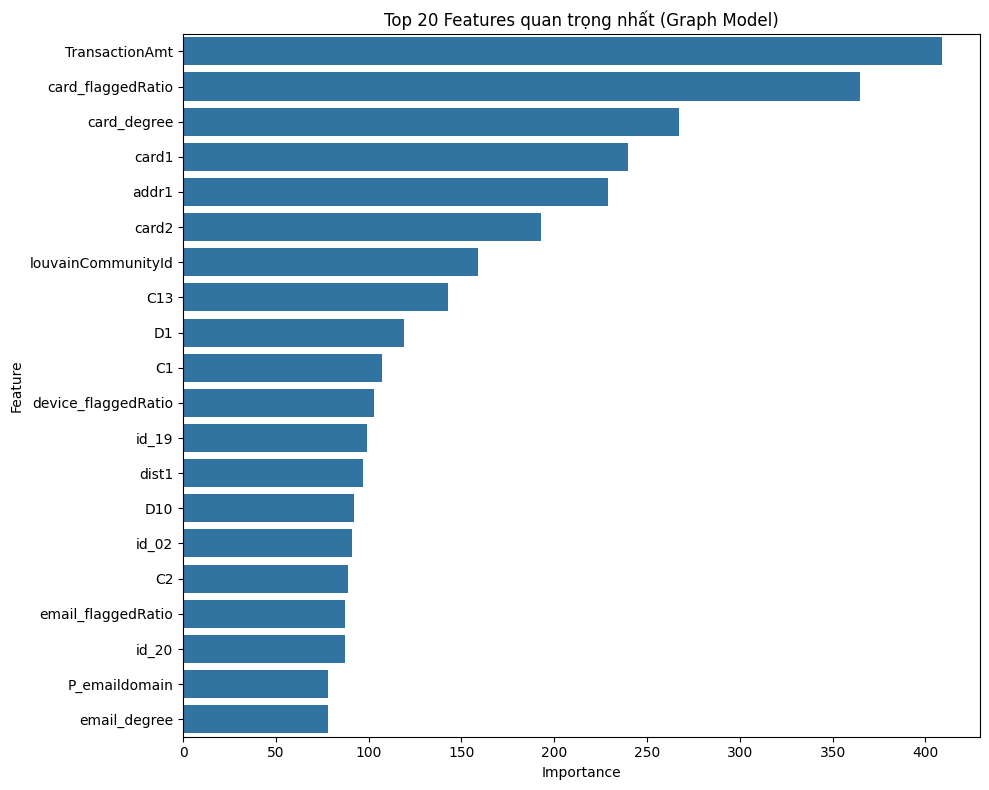

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = clf_graph.feature_importances_
features = X_graph.columns
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(20))
plt.title('Top 20 Features quan trọng nhất (Graph Model)')
plt.tight_layout()
plt.show()
